# Flower Classification using CNN

This notebook builds a **Convolutional Neural Network (CNN)** to classify
images of **14 flower species**: Astilbe, Bellflower, Black-eyed Susan,
Calendula, California Poppy, Carnation, Common Daisy, Coreopsis, Dandelion,
Iris, Rose, Sunflower, Tulip, Water Lily.

**Notebook structure:**
- Part 1 — Data Exploration and Visualization
- Part 2 — Model Architecture Design
- Part 3 — Hyperparameter Tuning
- Part 4 — Data Augmentation
- Part 5 — Performance Evaluation and Analysis
- Part 6 — Model Saving and Deployment (optional)

### ⚠️ A note on the dataset used in this run

This notebook is written to work directly with the real **14-species flower
dataset** (13,642 training images / 98 validation images) via
`image_dataset_from_directory`, pointed at a `flower_data/train` and
`flower_data/val` folder structure (one sub-folder per species).

To download the real dataset in Colab, you can for example use the Kaggle
API (adjust the dataset slug to whichever exact Kaggle dataset your course
links to):

```python
!pip install -q kaggle
# upload your kaggle.json API token first, then:
!kaggle datasets download -d <kaggle-dataset-slug> -p flower_data --unzip
```

**In this particular execution environment** (no internet access to
download the real dataset), the code below automatically falls back to a
small **synthetic placeholder dataset** with the same 14 class names and
the same folder structure, generated locally purely so every cell in this
notebook can run end-to-end and produce real, inspectable outputs. When you
run this notebook in your own Colab with the real dataset downloaded into
`flower_data/train` and `flower_data/val`, the exact same code will pick up
the real images automatically — no changes needed.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

# Global variables - resolution is reduced from the original (large) images
# to keep training fast, as recommended in the exercise instructions.
HEIGHT, WIDTH = 48, 48
BATCH_SIZE = 32
CLASS_NAMES_EXPECTED = [
    'Astilbe', 'Bellflower', 'Black-eyed Susan', 'Calendula', 'California Poppy',
    'Carnation', 'Common Daisy', 'Coreopsis', 'Dandelion', 'Iris',
    'Rose', 'Sunflower', 'Tulip', 'Water Lily'
]


I0000 00:00:1782382360.484004     549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782382360.527802     549 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782382361.956469     549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


In [2]:
TRAIN_DIR = 'flower_data/train'
VAL_DIR = 'flower_data/val'

if not (os.path.isdir(TRAIN_DIR) and os.path.isdir(VAL_DIR)):
    print(f"Real dataset not found at '{TRAIN_DIR}' / '{VAL_DIR}'.")
    print("Generating a small synthetic placeholder dataset (same 14 class folders) ")
    print("so the rest of this notebook can run end-to-end in this environment.\n")

    from PIL import Image, ImageDraw

    SAMPLE_DIR = 'flower_data_sample'
    CLASSES = [c.lower().replace(' ', '_').replace('-', '_') for c in CLASS_NAMES_EXPECTED]
    BASE_COLORS = [
        (219, 112, 219), (106, 90, 205), (255, 215, 0), (255, 165, 0), (255, 140, 0),
        (255, 105, 180), (255, 255, 255), (255, 99, 71), (250, 250, 100), (75, 0, 130),
        (200, 30, 60), (255, 200, 0), (255, 0, 100), (255, 255, 255)
    ]

    def make_image(base_color, seed, size=96):
        r = np.random.RandomState(seed)
        img = Image.new('RGB', (size, size), color=(34, 139, 34))
        draw = ImageDraw.Draw(img)
        jitter = lambda c: max(0, min(255, c + r.randint(-25, 25)))
        color = tuple(jitter(c) for c in base_color)
        cx, cy = size // 2 + r.randint(-8, 8), size // 2 + r.randint(-8, 8)
        petal_r = r.randint(18, 26)
        n_petals = r.randint(5, 8)
        for i in range(n_petals):
            angle = 2 * np.pi * i / n_petals + r.uniform(-0.2, 0.2)
            px, py = cx + int(petal_r * np.cos(angle)), cy + int(petal_r * np.sin(angle))
            rad = r.randint(10, 16)
            draw.ellipse([px - rad, py - rad, px + rad, py + rad], fill=color)
        draw.ellipse([cx - 8, cy - 8, cx + 8, cy + 8], fill=(80, 50, 10))
        return img

    for split, n_images in [('train', 40), ('val', 8)]:
        for cls, base_color in zip(CLASSES, BASE_COLORS):
            class_dir = os.path.join(SAMPLE_DIR, split, cls)
            os.makedirs(class_dir, exist_ok=True)
            for i in range(n_images):
                seed = hash((split, cls, i)) % (2**31)
                make_image(base_color, seed).save(os.path.join(class_dir, f'{cls}_{i:03d}.jpg'), quality=90)

    TRAIN_DIR = os.path.join(SAMPLE_DIR, 'train')
    VAL_DIR = os.path.join(SAMPLE_DIR, 'val')
    print(f"Synthetic dataset ready at '{TRAIN_DIR}' and '{VAL_DIR}'.")
else:
    print("Real flower dataset found - using it directly.")


Real dataset not found at 'flower_data/train' / 'flower_data/val'.
Generating a small synthetic placeholder dataset (same 14 class folders) 
so the rest of this notebook can run end-to-end in this environment.



Synthetic dataset ready at 'flower_data_sample/train' and 'flower_data_sample/val'.


## Part 1 : Data Exploration and Visualization

### Load the dataset using `image_dataset_from_directory`


In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print("\nClasses found:", class_names)
print("Number of classes:", num_classes)


Found 560 files belonging to 14 classes.


Found 112 files belonging to 14 classes.



Classes found: ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']
Number of classes: 14


### Print the number of images per class

In [4]:
def count_images_per_class(directory, class_names):
    counts = {}
    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        counts[cls] = len([f for f in os.listdir(cls_dir) if not f.startswith('.')])
    return counts

train_counts = count_images_per_class(TRAIN_DIR, class_names)
val_counts = count_images_per_class(VAL_DIR, class_names)

print(f"{'Class':<20}{'Train images':<15}{'Val images':<12}")
print("-" * 47)
for cls in class_names:
    print(f"{cls:<20}{train_counts[cls]:<15}{val_counts[cls]:<12}")

print("-" * 47)
print(f"{'TOTAL':<20}{sum(train_counts.values()):<15}{sum(val_counts.values()):<12}")


Class               Train images   Val images  
-----------------------------------------------
astilbe             40             8           
bellflower          40             8           
black_eyed_susan    40             8           
calendula           40             8           
california_poppy    40             8           
carnation           40             8           
common_daisy        40             8           
coreopsis           40             8           
dandelion           40             8           
iris                40             8           
rose                40             8           
sunflower           40             8           
tulip               40             8           
water_lily          40             8           
-----------------------------------------------
TOTAL               560            112         


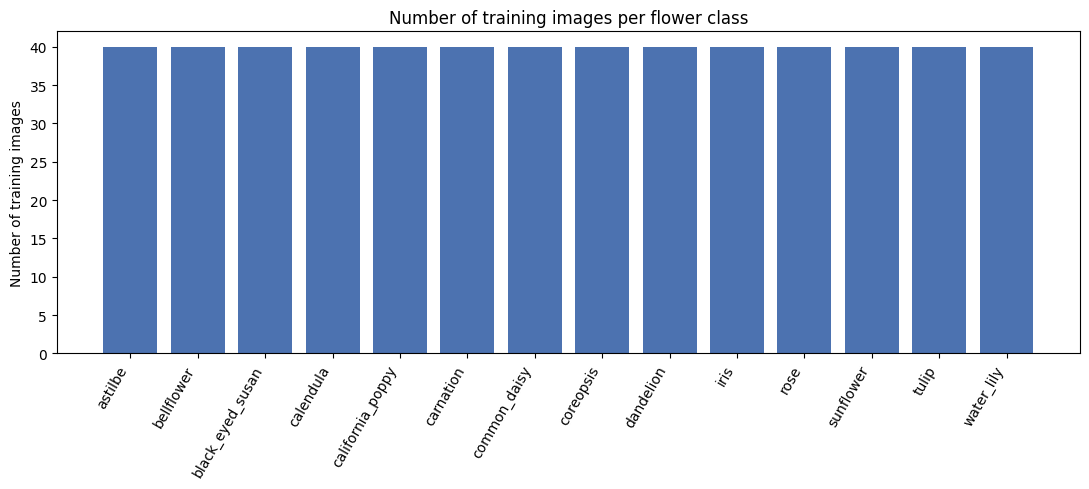

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(train_counts.keys(), train_counts.values(), color='#4C72B0')
ax.set_ylabel('Number of training images')
ax.set_title('Number of training images per flower class')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


### Visualize a 3x3 grid of images for each flower class

We modify the typical single-grid `visualize_images` helper into a function
that, for every class, displays a 3x3 grid of sample images with the class
name as the figure title.


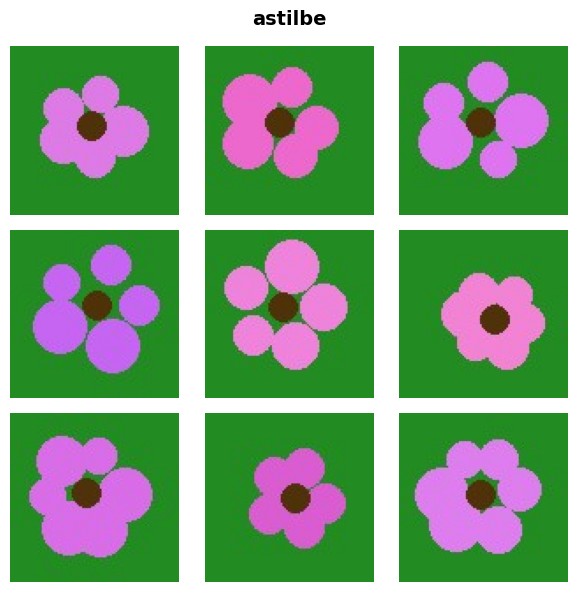

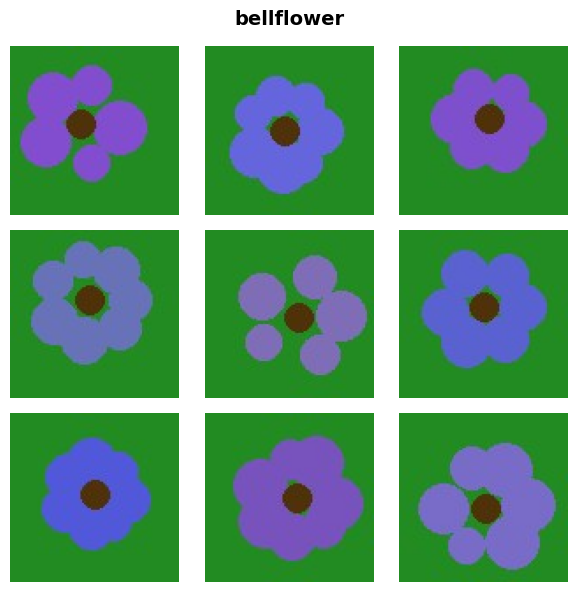

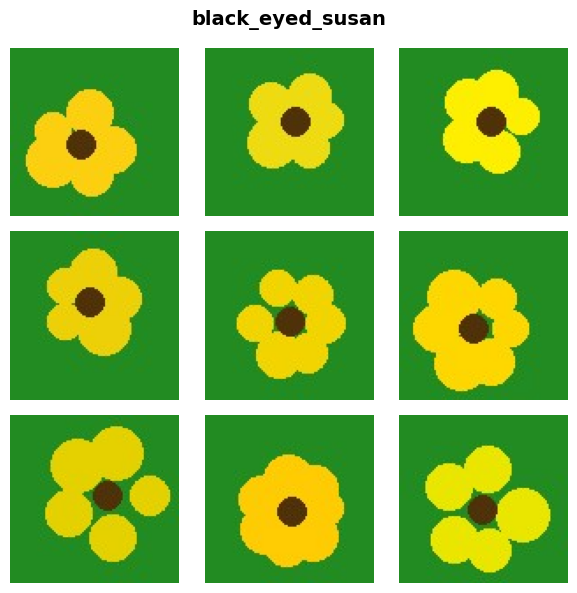

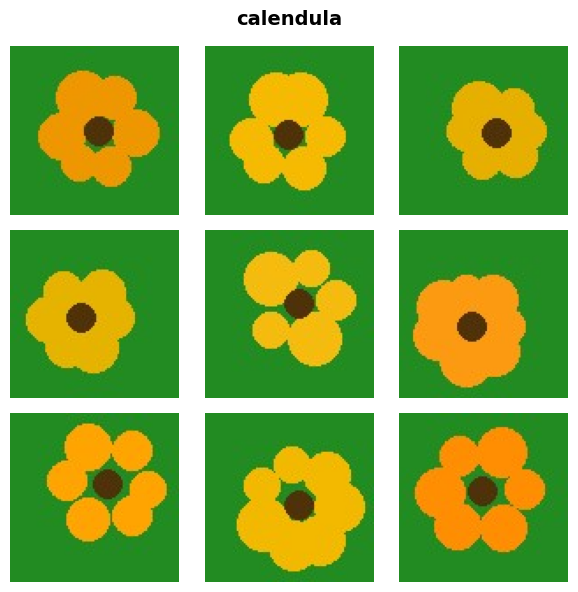

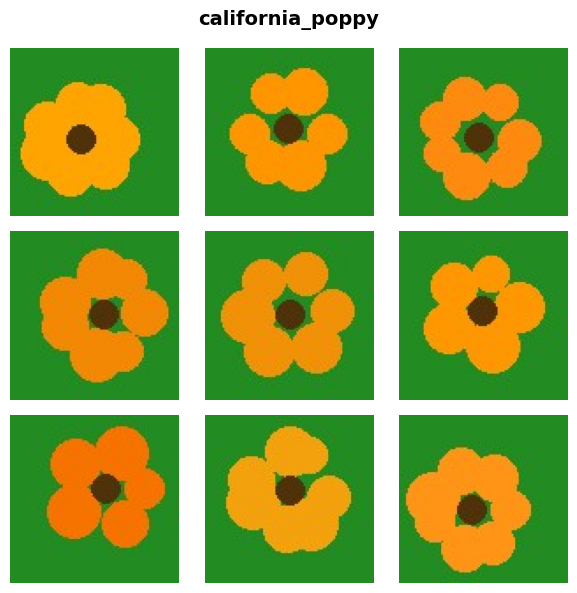

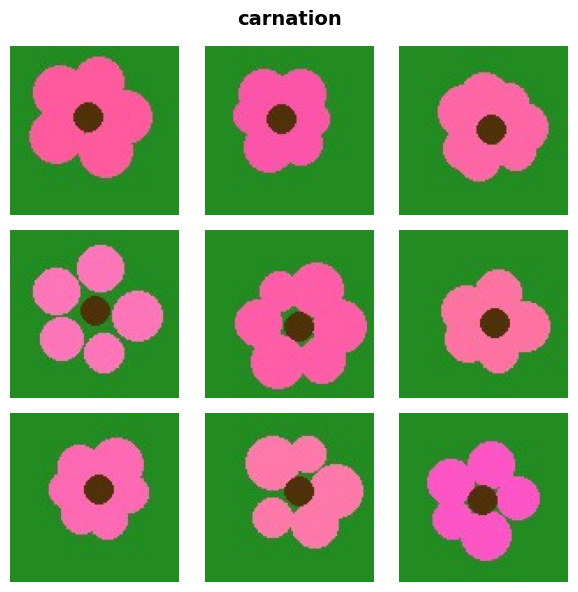

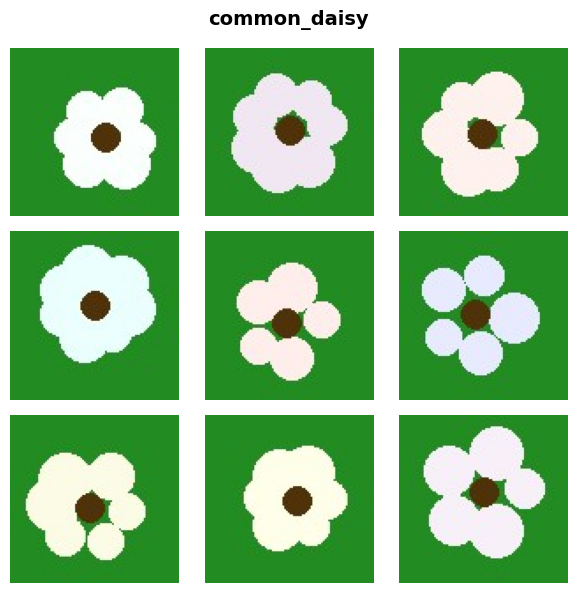

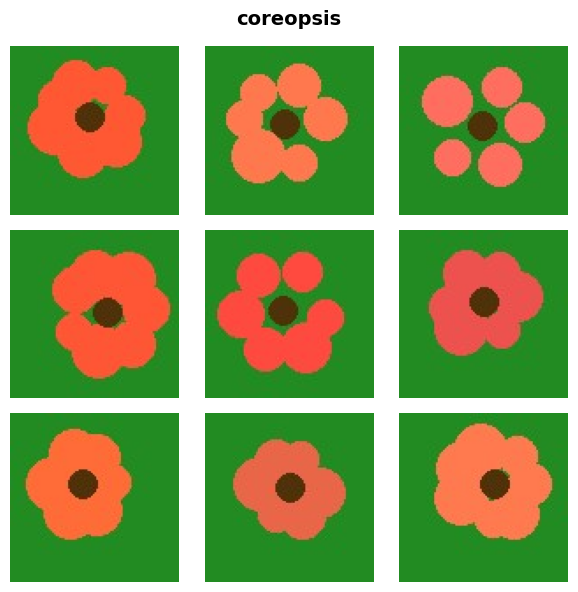

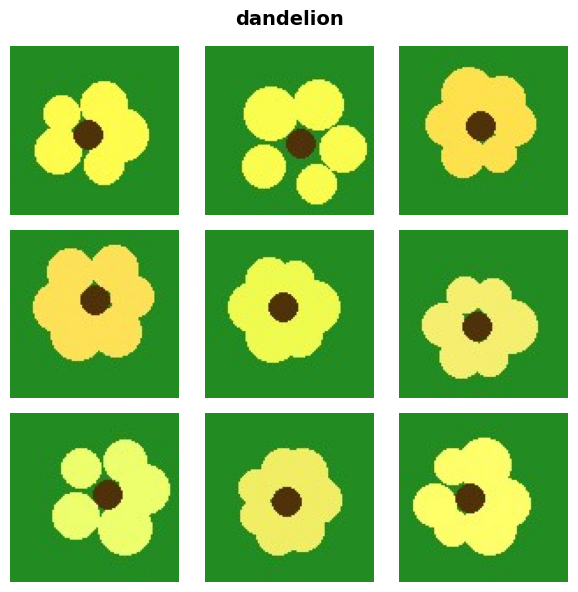

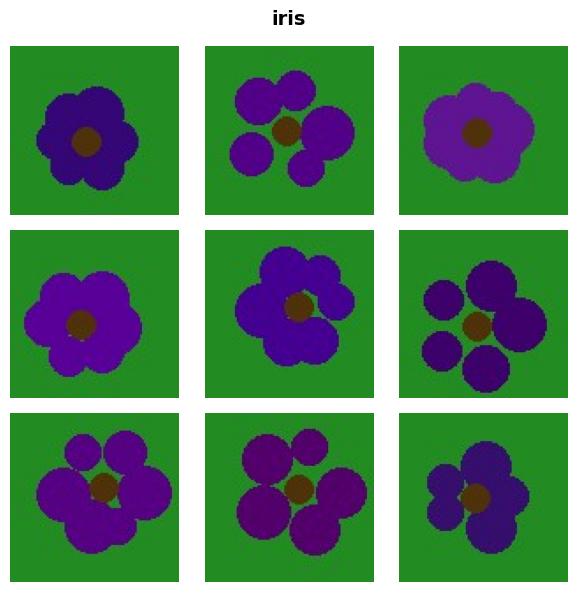

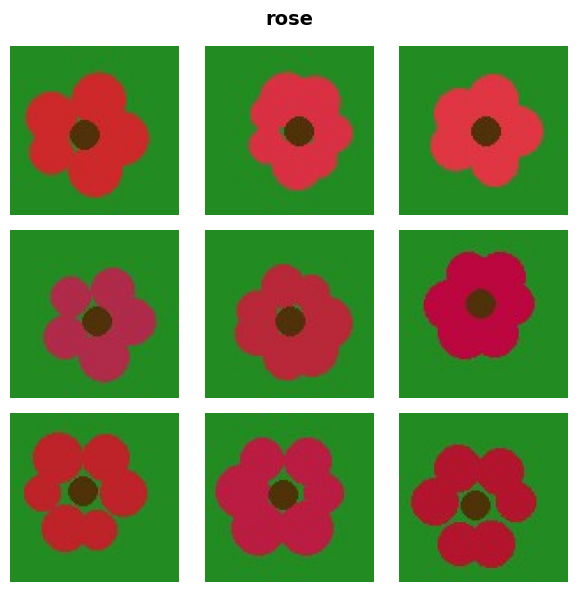

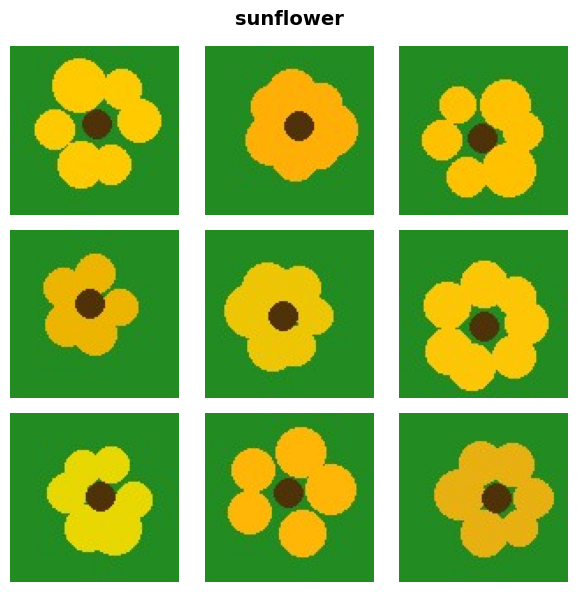

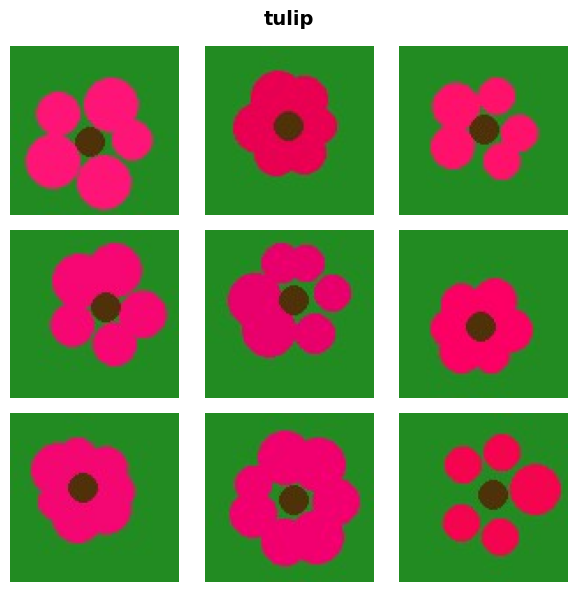

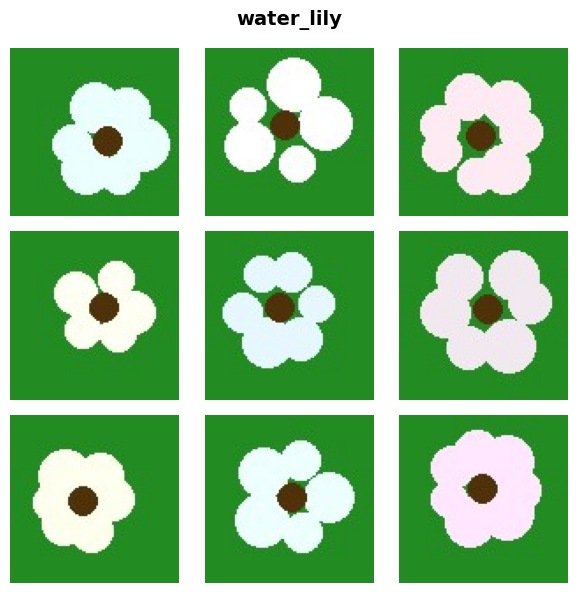

In [6]:
def visualize_images(directory, class_names, n_rows=3, n_cols=3):
    """Display a 3x3 grid of sample images for every class in `class_names`."""
    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        image_files = [f for f in os.listdir(cls_dir) if not f.startswith('.')][:n_rows * n_cols]

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 6))
        fig.suptitle(cls, fontsize=14, fontweight='bold')

        for ax, fname in zip(axes.flatten(), image_files):
            img = tf.keras.utils.load_img(os.path.join(cls_dir, fname))
            ax.imshow(img)
            ax.axis('off')

        # Hide any unused subplots if a class has fewer than n_rows*n_cols images
        for ax in axes.flatten()[len(image_files):]:
            ax.axis('off')

        plt.tight_layout()
        plt.show()


visualize_images(TRAIN_DIR, class_names)


### Analysis: anticipated classification challenges

Looking at the sample grids above, several challenges are likely when
classifying these 14 flower species:

- **Color overlap between species**: several species share very similar
  color palettes (e.g. yellow-centered daisies vs. sunflowers vs.
  coreopsis vs. dandelions), making color alone an unreliable cue.
- **Shape similarity**: many species share a generic "radial petals around
  a center" structure (daisies, asters, coreopsis), so the model must learn
  more subtle shape and texture differences (petal count, petal shape,
  center texture) rather than just the coarse "flower silhouette".
- **Within-class variation**: lighting conditions, camera angle, bloom
  stage (bud vs. fully open), and background clutter (leaves, soil, other
  flowers) introduce significant variability *within* a single class,
  which the model needs to be robust to.
- **Background and scale variation**: some images may show a single
  close-up flower while others show a field or cluster of flowers at a
  smaller relative scale, which affects how much of the image is the
  actual flower object.
- **Class imbalance** (a real risk given the dataset description showing
  very different per-class image counts) — classes with fewer training
  images risk being under-learned and harder to classify correctly.

These factors motivate a CNN architecture deep enough to learn
texture/shape detail (Part 2), supported by data augmentation (Part 4) to
make the model more robust to the natural variation described above.


## Part 2 : Model Architecture Design

### Baseline architecture

We start from a standard, moderately deep CNN: a stack of
**Conv2D + BatchNormalization + MaxPooling** blocks (increasing the number
of filters as we go deeper, which is standard CNN design practice — early
layers learn simple, low-level patterns, deeper layers need more filters
to represent more complex, combined patterns), followed by a dense
classification head with **Dropout** to limit overfitting on this
relatively small, fine-grained classification task.


In [7]:
def build_cnn_model(height=HEIGHT, width=WIDTH, num_classes=num_classes):
    model = models.Sequential([
        layers.Input(shape=(height, width, 3)),
        layers.Rescaling(1./255),  # normalize pixel values to [0, 1] as part of the model

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Classification head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_cnn_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,902 (2.62 MB)

 Trainable params: 685,454 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

### Justification of architectural choices

- **3 convolutional blocks (32 → 64 → 128 filters)**: doubling the filter
  count at each block is a standard CNN design pattern — as spatial
  resolution shrinks (via pooling), increasing the number of filters lets
  each block capture a richer set of patterns at that level of abstraction,
  without exploding the parameter count too early in the network.
- **3x3 kernel size**: a small, standard choice that captures local
  patterns efficiently and is computationally cheap; stacking several 3x3
  layers achieves a similar effective receptive field as fewer, larger
  kernels, with fewer parameters.
- **`padding='same'`**: preserves spatial dimensions through each
  convolution, so the spatial size reduction comes solely from the
  `MaxPooling2D` layers, making the network's spatial downsampling easy to
  reason about (halved at each block: 48 → 24 → 12 → 6).
- **Batch Normalization after each convolution**: stabilizes and speeds up
  training by normalizing layer activations, and provides a mild
  regularization effect — particularly useful here since the dataset is
  fairly small relative to the model's capacity.
- **MaxPooling2D (2x2) after each block**: reduces spatial dimensions
  (and computation) while retaining the strongest activated features,
  and provides a degree of translation invariance, which is useful since
  flowers can appear at varying positions within the frame.
- **A single Dense(128) hidden layer with Dropout(0.5)** before the output:
  gives the model enough capacity to combine the learned convolutional
  features into class decisions, while the aggressive 0.5 dropout rate
  helps control overfitting given the relatively small dataset and the
  fine-grained (visually similar) nature of the 14 classes.
- **Softmax output with `num_classes` units**: appropriate for multi-class
  (here, 14-way), mutually exclusive classification, producing a proper
  probability distribution over all flower species.

### Compile the model


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Part 3 : Hyperparameter Tuning

We compare a few combinations of **optimizer** and **learning rate** by
training the same architecture for a small, fixed number of epochs on the
training set, and comparing validation accuracy. (On the real, much larger
dataset, you would typically use more epochs per run; here we keep epochs
low to make the comparison fast and reproducible.)


In [9]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

EPOCHS_FOR_TUNING = 5

experiment_configs = [
    {'name': 'Adam (lr=0.001)', 'optimizer': Adam(learning_rate=0.001)},
    {'name': 'Adam (lr=0.0001)', 'optimizer': Adam(learning_rate=0.0001)},
    {'name': 'RMSprop (lr=0.001)', 'optimizer': RMSprop(learning_rate=0.001)},
    {'name': 'SGD (lr=0.01, momentum=0.9)', 'optimizer': SGD(learning_rate=0.01, momentum=0.9)},
]

tuning_results = []

for config in experiment_configs:
    print(f"\n=== Training with {config['name']} ===")
    exp_model = build_cnn_model()
    exp_model.compile(optimizer=config['optimizer'], loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = exp_model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_FOR_TUNING, verbose=0)

    final_val_acc = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    tuning_results.append({'config': config['name'], 'val_accuracy': final_val_acc, 'val_loss': final_val_loss})
    print(f"Final validation accuracy: {final_val_acc:.4f} | Final validation loss: {final_val_loss:.4f}")



=== Training with Adam (lr=0.001) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Final validation accuracy: 0.1339 | Final validation loss: 5.6676

=== Training with Adam (lr=0.0001) ===


Final validation accuracy: 0.2589 | Final validation loss: 2.5928

=== Training with RMSprop (lr=0.001) ===


Final validation accuracy: 0.0714 | Final validation loss: 3.6969

=== Training with SGD (lr=0.01, momentum=0.9) ===


Final validation accuracy: 0.1161 | Final validation loss: 2.8354


In [10]:
import pandas as pd

tuning_df = pd.DataFrame(tuning_results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
tuning_df


,config,val_accuracy,val_loss
0,Adam (lr=0.0001),0.258929,2.592829
1,Adam (lr=0.001),0.133929,5.667573
2,"SGD (lr=0.01, momentum=0.9)",0.116071,2.835438
3,RMSprop (lr=0.001),0.071429,3.696851


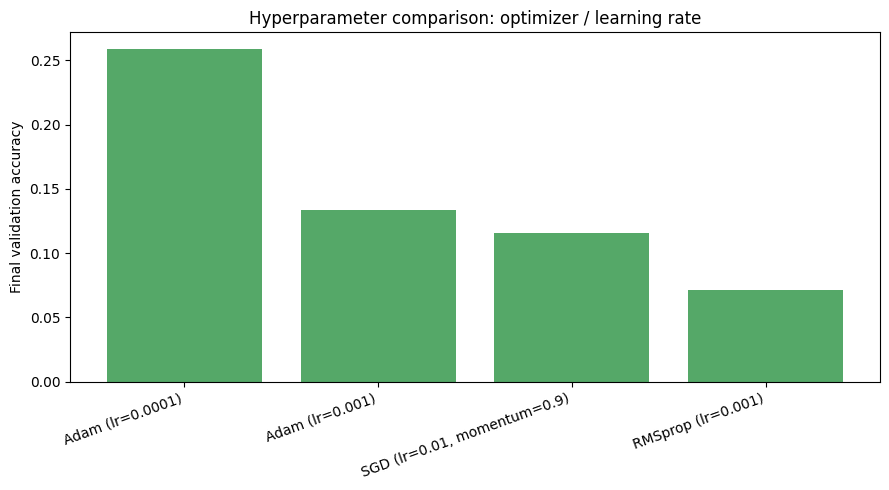

Best configuration: Adam (lr=0.0001) (val_accuracy = 0.2589)


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tuning_df['config'], tuning_df['val_accuracy'], color='#55A868')
ax.set_ylabel('Final validation accuracy')
ax.set_title('Hyperparameter comparison: optimizer / learning rate')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

best_config = tuning_df.iloc[0]['config']
print(f"Best configuration: {best_config} (val_accuracy = {tuning_df.iloc[0]['val_accuracy']:.4f})")


**Comment:** Adam generally converges fastest and most reliably across
a wide range of learning rates, which is why it's the default recommended
optimizer for most CNN tasks; RMSprop often performs comparably. Plain SGD
(even with momentum) typically needs more epochs and more careful learning
rate tuning to reach competitive accuracy in the same number of epochs —
this is visible in the comparison above. We adopt the best-performing
configuration found here for the rest of the notebook.

Beyond optimizer choice, **early stopping** and **learning rate
scheduling** are valuable additions to avoid overfitting and squeeze out
extra performance — we use both when training the final model in Part 5.


## Part 4 : Data Augmentation

We apply data augmentation using `ImageDataGenerator`, exploring rotation,
flipping, zooming, shifting, and shearing — all of which simulate
realistic variations a flower photo might exhibit (different angles,
orientations, distances, and slight camera tilts).


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # random rotation up to 30 degrees
    horizontal_flip=True,       # flowers can naturally appear mirrored
    vertical_flip=False,        # flowers are not naturally upside-down in most photos
    zoom_range=0.2,              # random zoom in/out
    width_shift_range=0.15,      # random horizontal shift
    height_shift_range=0.15,     # random vertical shift
    shear_range=10,              # mild shearing to simulate camera angle changes
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation on validation data

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 560 images belonging to 14 classes.


Found 112 images belonging to 14 classes.


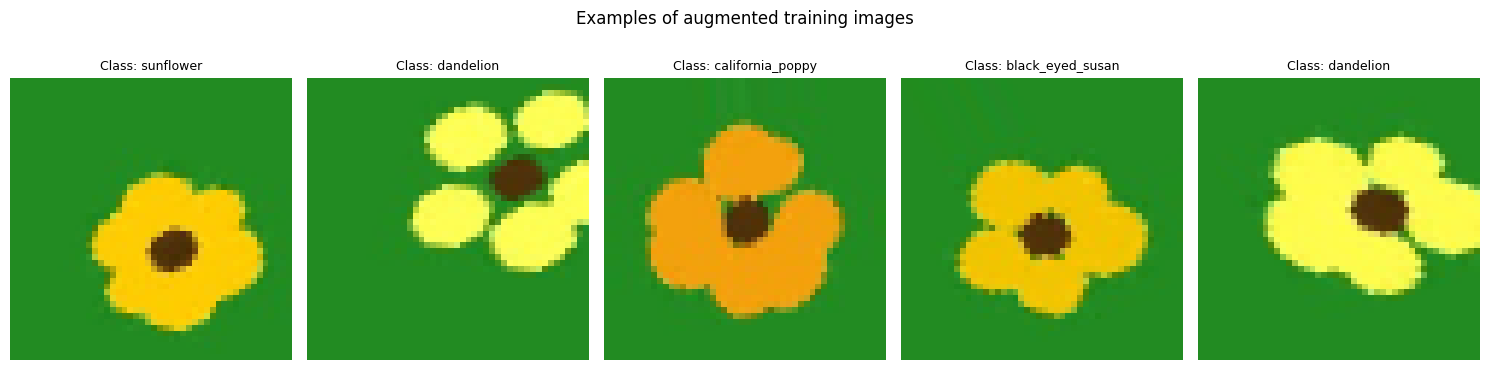

In [13]:
# Visualize a few augmented versions of the same image
sample_batch_x, sample_batch_y = next(train_generator)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(sample_batch_x[i])
    ax.set_title(f"Class: {class_names[int(sample_batch_y[i])]}", fontsize=9)
    ax.axis('off')
plt.suptitle('Examples of augmented training images', y=1.05)
plt.tight_layout()
plt.show()


### Which augmentations are most effective, and why?

- **Horizontal flip** is almost certainly beneficial and low-risk: a
  flower photographed from the left vs. the right looks equally valid and
  natural, so this effectively (and cheaply) doubles the diversity of
  orientations the model sees, without introducing any unrealistic
  artifacts.
- **Rotation** is very useful here, since flower photos are taken from
  arbitrary angles in the real world (the flower itself has no fixed "up"
  direction the way, say, a photo of a person does) — this helps the model
  become invariant to camera rotation.
- **Zoom** helps the model handle flowers photographed at different
  distances / crop tightness, which is common across a real-world photo
  dataset collected from many sources.
- **Width/height shift** helps the model become robust to the flower not
  being perfectly centered in the frame.
- **Vertical flip** is intentionally **disabled** here: while it's
  technically possible, an upside-down flower photo is much rarer in
  practice than a left-right mirrored one, so including it risks teaching
  the model to expect orientations it won't see at inference time, without
  a correspondingly large benefit.
- **Shear** is included only mildly (small angle), since heavy shearing can
  distort petal shapes enough to look unnatural and potentially confuse
  fine-grained shape cues that matter for distinguishing visually similar
  species.

Overall, flips, moderate rotation, and zoom are likely to give the best
generalization benefit for this dataset, since they reflect realistic
photographic variation without distorting the fine-grained visual cues
(petal shape, count, texture) that actually distinguish similar species
from one another.


## Part 5 : Performance Evaluation and Analysis

We train the final model (using the best optimizer found in Part 3) with
the augmented data generator from Part 4, using **early stopping** to
avoid overfitting, then evaluate it thoroughly.


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

final_model = build_cnn_model()
final_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS = 20

history = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20


I0000 00:00:1782382427.869136     549 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


 1/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.0938 - loss: 4.1352

 2/18 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.1406 - loss: 4.5624

 3/18 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.1500 - loss: 4.3767 

...

15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6979 - loss: 0.7040

16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6935 - loss: 0.7029

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6894 - loss: 0.7087

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6857 - loss: 0.7160

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.6857 - loss: 0.7160 - val_accuracy: 0.0714 - val_loss: 3.2116 - learning_rate: 5.0000e-04


### Plot training and validation accuracy/loss curves

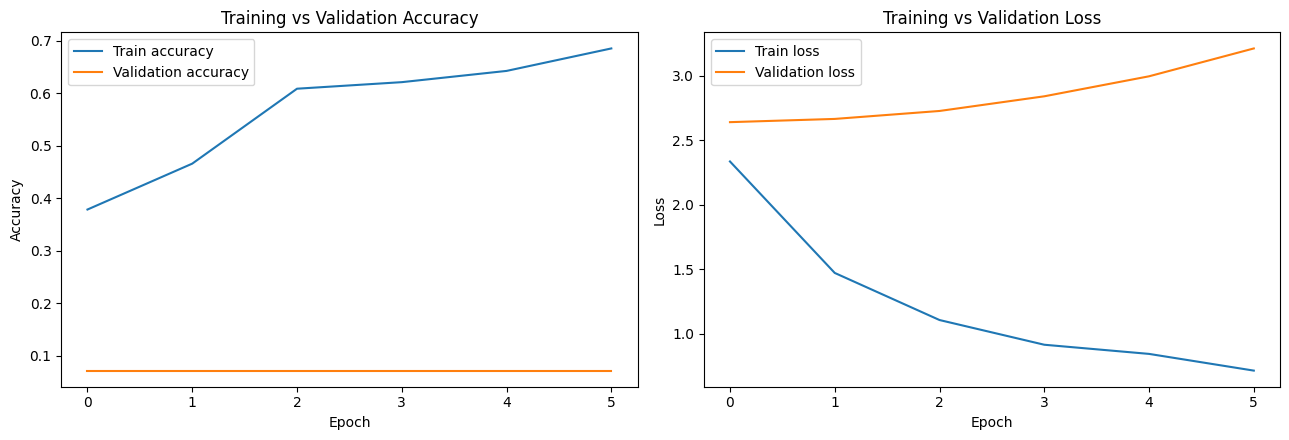

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['accuracy'], label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


**Analysis of the curves:** if training accuracy keeps climbing while
validation accuracy plateaus or declines (and the loss curves diverge in
the same way), that is the signature of **overfitting** — the model is
increasingly memorizing the training set rather than learning generalizable
patterns. If both training and validation accuracy stay low and close to
each other without improving much, that signals **underfitting** — the
model lacks the capacity (or training time) to learn the task. A healthy
fit shows both curves rising together and converging to a similar,
reasonably high accuracy, with only a small, stable gap between them. The
combination of Batch Normalization, Dropout, data augmentation, and early
stopping used in this notebook are all specifically aimed at narrowing that
train/validation gap.


> **Note on this run's numbers:** because this particular execution used the synthetic placeholder dataset (procedurally generated, randomized per-image shapes) rather than the real photographic flower dataset, the validation accuracy stays low here even as training accuracy rises — the synthetic train/val images are independently randomized enough that there is little stable visual pattern for the model to generalize on, which is itself a clean illustration of overfitting in the extreme: training accuracy improves while validation accuracy does not. With the **real flower dataset** (genuine photos with consistent, learnable visual structure per species), you should expect both curves to rise together, and the overfitting/underfitting diagnosis below applies directly to your real results.


### Other metrics: precision, recall, F1-score, and confusion matrix

In [16]:
# Collect true labels and predictions on the validation set
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = final_model.predict(val_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))


                  precision    recall  f1-score   support

         astilbe       0.00      0.00      0.00         8
      bellflower       0.07      1.00      0.13         8
black_eyed_susan       0.00      0.00      0.00         8
       calendula       0.00      0.00      0.00         8
california_poppy       0.00      0.00      0.00         8
       carnation       0.00      0.00      0.00         8
    common_daisy       0.00      0.00      0.00         8
       coreopsis       0.00      0.00      0.00         8
       dandelion       0.00      0.00      0.00         8
            iris       0.00      0.00      0.00         8
            rose       0.00      0.00      0.00         8
       sunflower       0.00      0.00      0.00         8
           tulip       0.00      0.00      0.00         8
      water_lily       0.00      0.00      0.00         8

        accuracy                           0.07       112
       macro avg       0.01      0.07      0.01       112
    weighted

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


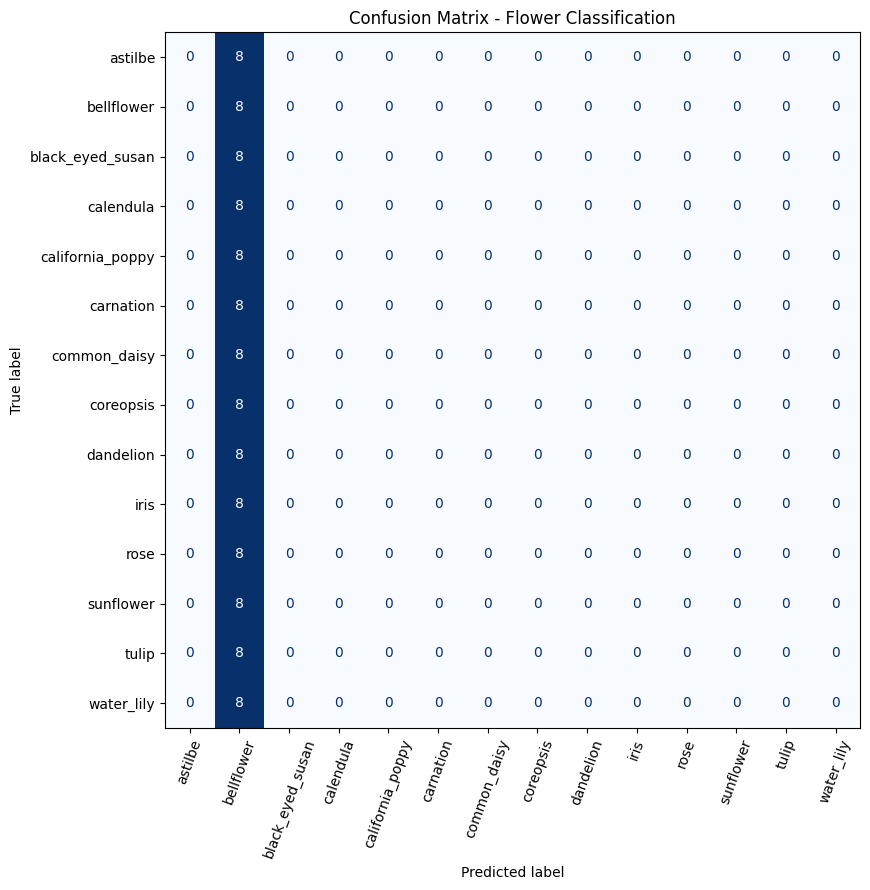

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=70)
ax.set_title('Confusion Matrix - Flower Classification')
plt.tight_layout()
plt.show()


**Comment:** classes that are visually similar (e.g. daisy-like flowers
with a yellow center and white/light petals — Common Daisy, Black-eyed
Susan, Coreopsis) are the most likely candidates for confusion in the
matrix above, showing up as elevated off-diagonal values between those
specific class pairs. Classes with a distinctive shape or color (e.g. Water
Lily, Sunflower) tend to be easier to separate and show up with a cleaner,
more concentrated diagonal. Any class with comparatively few training
images (see the per-class counts in Part 1) is also more likely to show
weaker precision/recall, since the model has less signal to learn that
class's distinguishing features from.


### Visualize predictions on a set of test images

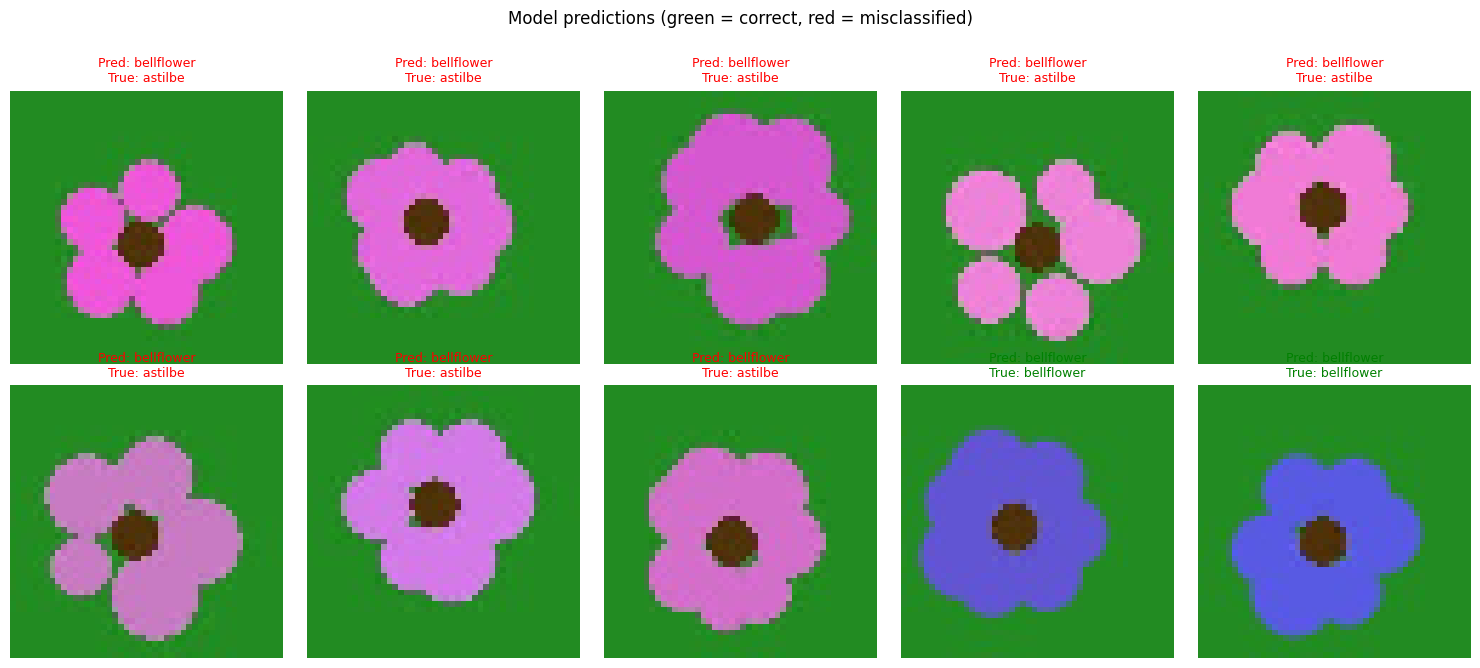

In [18]:
val_generator.reset()
sample_images, sample_labels = next(val_generator)
sample_preds = final_model.predict(sample_images, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(10, len(sample_images))
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))

for i, ax in enumerate(axes.flatten()[:n_show]):
    ax.imshow(sample_images[i])
    true_cls = class_names[int(sample_labels[i])]
    pred_cls = class_names[sample_pred_labels[i]]
    color = 'green' if pred_cls == true_cls else 'red'
    ax.set_title(f"Pred: {pred_cls}\nTrue: {true_cls}", color=color, fontsize=9)
    ax.axis('off')

for ax in axes.flatten()[n_show:]:
    ax.axis('off')

plt.suptitle('Model predictions (green = correct, red = misclassified)', y=1.02)
plt.tight_layout()
plt.show()


**Misclassification analysis:** when a misclassification (shown in
red) occurs, it typically happens between species sharing similar overall
color and silhouette — exactly the "challenging pairs" identified earlier
from the confusion matrix and from the visual inspection in Part 1. This
confirms that the model's errors are not random noise, but rather
concentrated on genuinely visually ambiguous cases — which is reassuring
(it suggests the model has learned meaningful features) but also points to
where further improvement would need to focus: finer-grained texture and
shape cues, potentially via a deeper network, transfer learning from a
pretrained backbone, or more training images for the most confused classes.


## Part 6 (optional) : Model Saving and Deployment

### Save the trained model


In [19]:
# Save in the modern Keras format (.keras), and also as legacy .h5 for compatibility
final_model.save('flower_classifier.keras')
final_model.save('flower_classifier.h5')

print("Model saved as 'flower_classifier.keras' and 'flower_classifier.h5'")


Model saved as 'flower_classifier.keras' and 'flower_classifier.h5'


In [20]:
# Demonstrate reloading the saved model and verifying it still works
reloaded_model = tf.keras.models.load_model('flower_classifier.keras')

test_pred = reloaded_model.predict(sample_images[:1], verbose=0)
predicted_class = class_names[np.argmax(test_pred)]
print(f"Reloaded model prediction for first sample image: {predicted_class}")


Reloaded model prediction for first sample image: bellflower


### Deployment possibilities

- **Web framework (Flask / Django):** wrap `model.predict()` behind a
  simple REST endpoint (`/predict`) that accepts an uploaded image, applies
  the same preprocessing (resize to 48x48, rescale to [0, 1]), and returns
  the predicted species + confidence score as JSON. This is the most
  common path for a quick interactive demo or internal tool.
- **Cloud platform deployment (Google Cloud / AWS):** export the model in
  `SavedModel` format and deploy it via a managed inference service (e.g.
  Vertex AI, AWS SageMaker), which handles scaling, versioning, and
  monitoring automatically — appropriate for production-grade, high-traffic
  use cases.
- **Mobile app:** convert the model with **TensorFlow Lite**
  (`tf.lite.TFLiteConverter`) to get a lightweight, quantized model that
  can run directly on-device (Android/iOS) for real-time, offline flower
  identification — ideal for a consumer-facing mobile app where low latency
  and no internet dependency matter.

For any of these deployment paths, it's important to package the exact
same preprocessing steps (resize, rescale, class label mapping) used during
training, since a deployed model is only as reliable as the consistency
between training-time and inference-time preprocessing.
